In [1]:
# 01_eda.ipynb - Exploratory Data Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("📊 Loading dataset...")

# Load the data
df = pd.read_csv('../data/raw/malaria_dataset.csv')
print(f"✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

📊 Loading dataset...
✅ Dataset loaded: 1200 rows, 8 columns


In [2]:
# Basic dataset information
print("📋 Dataset Info:")
print(df.info())
print("\n" + "="*50)

print("\n📊 Statistical Summary:")
print(df.describe())
print("\n" + "="*50)

print("\n🔍 First 5 rows:")
print(df.head())

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   county           1200 non-null   object        
 1   date             1200 non-null   datetime64[ns]
 2   year             1200 non-null   int64         
 3   month            1200 non-null   int64         
 4   confirmed_cases  1200 non-null   int64         
 5   rainfall_mm      1200 non-null   float64       
 6   temp_mean_c      1200 non-null   float64       
 7   humidity_pct     1200 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(1)
memory usage: 75.1+ KB
None


📊 Statistical Summary:
                      date         year        month  confirmed_cases  \
count                 1200  1200.000000  1200.000000      1200.000000   
mean   2019-12-16 10:48:00  2019.500000     6.500000       131.759167   
min    2015-01-01

In [3]:
# Check for missing values
print("❓ Missing values in each column:")
print(df.isnull().sum())

# Check data types
print("\n📊 Data types:")
print(df.dtypes)

❓ Missing values in each column:
county             0
date               0
year               0
month              0
confirmed_cases    0
rainfall_mm        0
temp_mean_c        0
humidity_pct       0
dtype: int64

📊 Data types:
county                     object
date               datetime64[ns]
year                        int64
month                       int64
confirmed_cases             int64
rainfall_mm               float64
temp_mean_c               float64
humidity_pct              float64
dtype: object


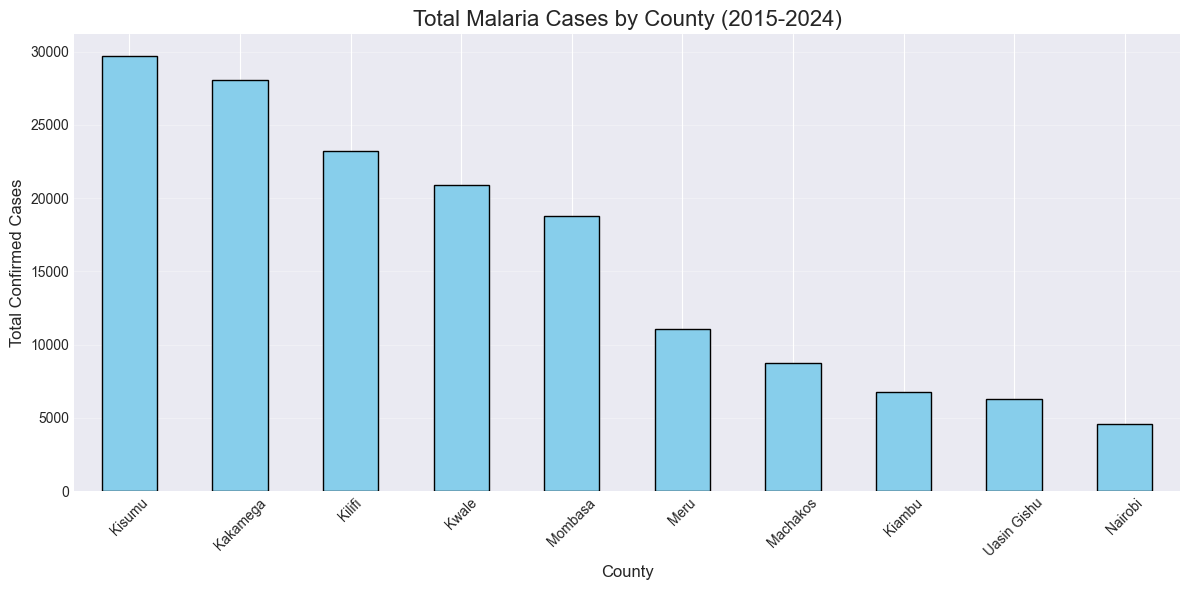

County with highest cases: Kisumu (29,686 cases)
County with lowest cases: Nairobi (4,602 cases)


In [4]:
# Total cases by county
total_cases = df.groupby('county')['confirmed_cases'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
total_cases.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Malaria Cases by County (2015-2024)', fontsize=16)
plt.xlabel('County', fontsize=12)
plt.ylabel('Total Confirmed Cases', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"County with highest cases: {total_cases.index[0]} ({total_cases.values[0]:,} cases)")
print(f"County with lowest cases: {total_cases.index[-1]} ({total_cases.values[-1]:,} cases)")

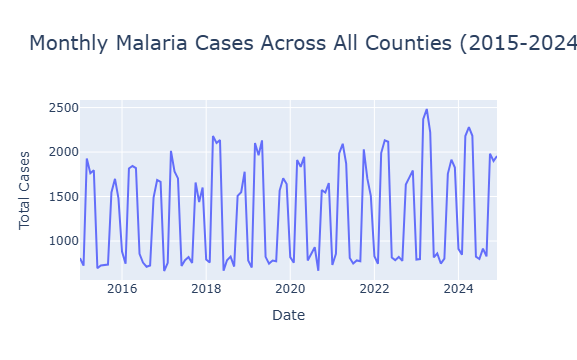

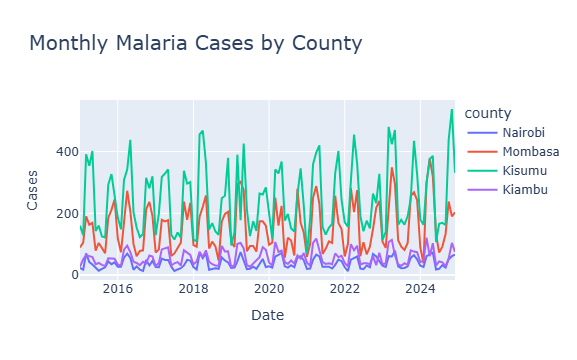

In [5]:
# Time series of cases over time (all counties combined)
monthly_cases = df.groupby('date')['confirmed_cases'].sum().reset_index()

fig = px.line(monthly_cases, x='date', y='confirmed_cases', 
              title='Monthly Malaria Cases Across All Counties (2015-2024)',
              labels={'confirmed_cases': 'Total Cases', 'date': 'Date'})
fig.update_layout(title_font_size=20)
fig.show()

# By county (select a few)
selected_counties = ['Kisumu', 'Nairobi', 'Mombasa', 'Kiambu']
filtered_df = df[df['county'].isin(selected_counties)]

fig2 = px.line(filtered_df, x='date', y='confirmed_cases', color='county',
               title='Monthly Malaria Cases by County',
               labels={'confirmed_cases': 'Cases', 'date': 'Date'})
fig2.update_layout(title_font_size=20)
fig2.show()

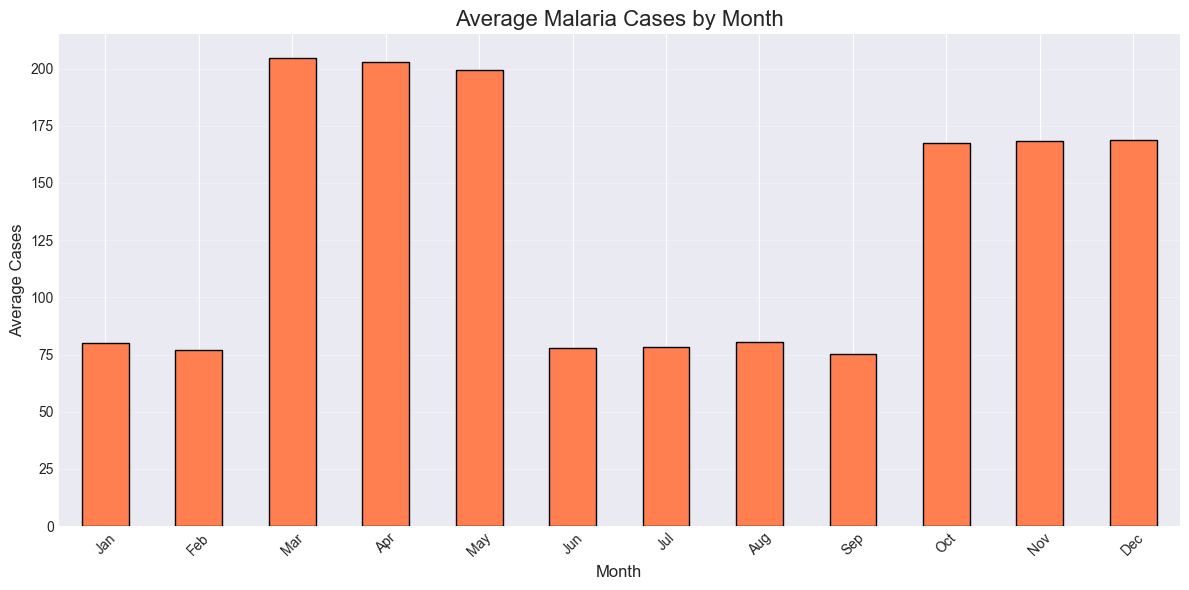

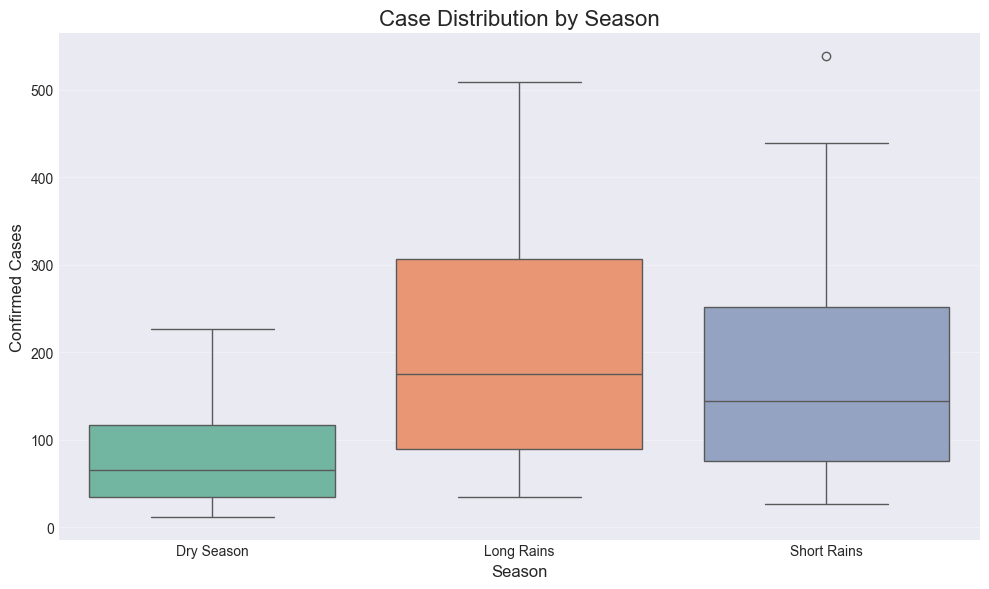

📊 Seasonal Statistics:
             count        mean         std   min    25%    50%     75%    max
season                                                                       
Dry Season   600.0   78.251667   48.582769  12.0  34.00   65.0  116.25  226.0
Long Rains   300.0  202.233333  123.704168  34.0  88.75  175.0  307.00  509.0
Short Rains  300.0  168.300000  101.703402  26.0  75.75  144.5  251.25  538.0


In [6]:
# Extract month and create season column
df['month'] = df['date'].dt.month

def get_season(month):
    if month in [3, 4, 5]:
        return 'Long Rains'
    elif month in [10, 11, 12]:
        return 'Short Rains'
    else:
        return 'Dry Season'

df['season'] = df['month'].apply(get_season)

# Average cases by month
monthly_avg = df.groupby('month')['confirmed_cases'].mean()

plt.figure(figsize=(12, 6))
monthly_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Malaria Cases by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Cases', fontsize=12)
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Boxplot by season
plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='confirmed_cases', data=df, palette='Set2')
plt.title('Case Distribution by Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Confirmed Cases', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print seasonal statistics
print("📊 Seasonal Statistics:")
print(df.groupby('season')['confirmed_cases'].describe())

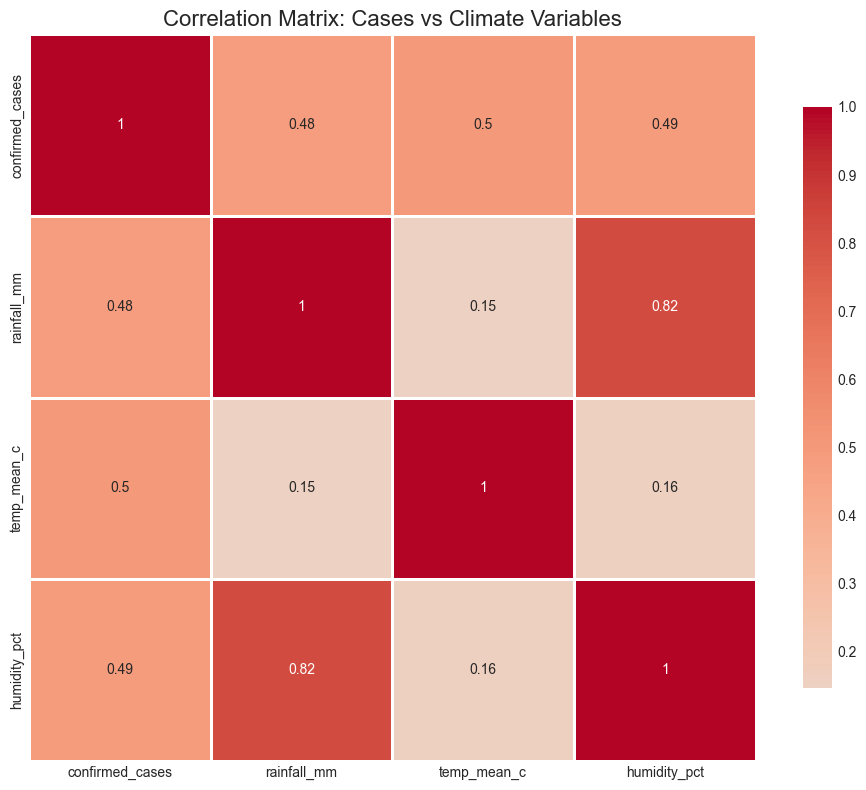

🔍 Strongest correlations with malaria cases:
   - temp_mean_c: 0.496 (moderate correlation)
   - humidity_pct: 0.486 (moderate correlation)
   - rainfall_mm: 0.482 (moderate correlation)


In [7]:
# Correlation between climate variables and cases
correlation_matrix = df[['confirmed_cases', 'rainfall_mm', 'temp_mean_c', 'humidity_pct']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Cases vs Climate Variables', fontsize=16)
plt.tight_layout()
plt.show()

print("🔍 Strongest correlations with malaria cases:")
corr_with_cases = correlation_matrix['confirmed_cases'].drop('confirmed_cases').sort_values(ascending=False)
for var, corr in corr_with_cases.items():
    strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
    print(f"   - {var}: {corr:.3f} ({strength} correlation)")

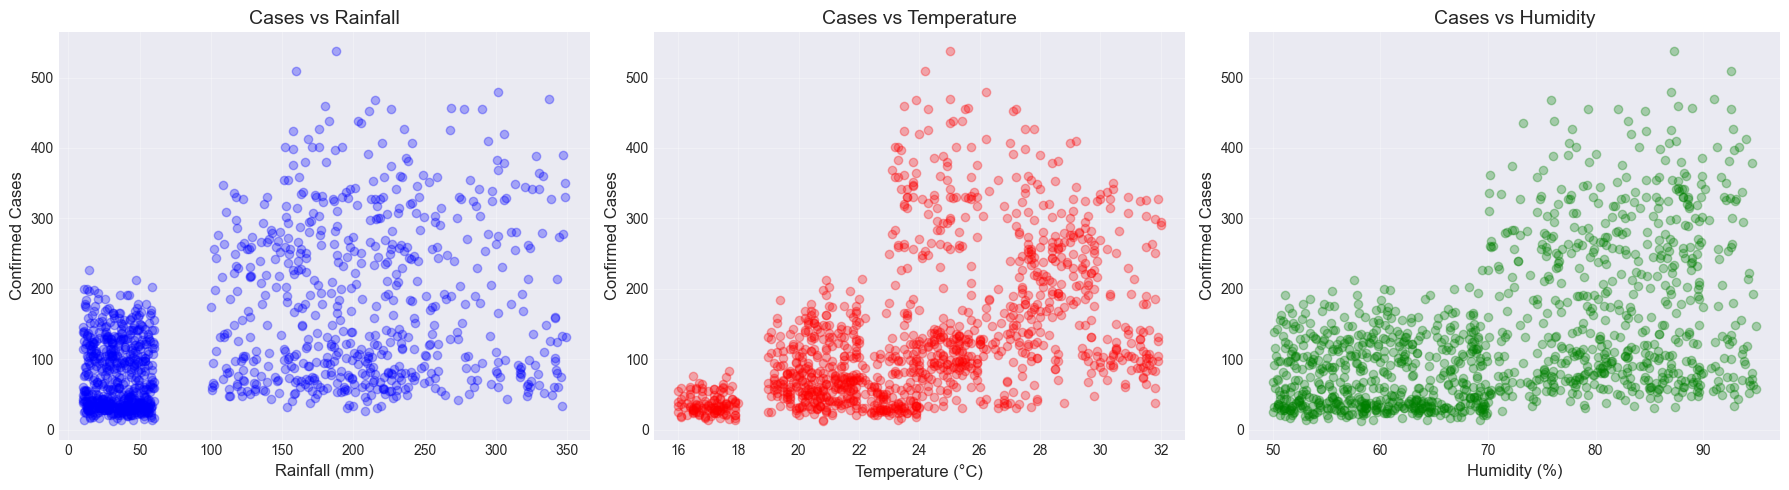

In [8]:
# Create scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cases vs Rainfall
axes[0].scatter(df['rainfall_mm'], df['confirmed_cases'], alpha=0.3, c='blue')
axes[0].set_xlabel('Rainfall (mm)', fontsize=12)
axes[0].set_ylabel('Confirmed Cases', fontsize=12)
axes[0].set_title('Cases vs Rainfall', fontsize=14)
axes[0].grid(alpha=0.3)

# Cases vs Temperature
axes[1].scatter(df['temp_mean_c'], df['confirmed_cases'], alpha=0.3, c='red')
axes[1].set_xlabel('Temperature (°C)', fontsize=12)
axes[1].set_ylabel('Confirmed Cases', fontsize=12)
axes[1].set_title('Cases vs Temperature', fontsize=14)
axes[1].grid(alpha=0.3)

# Cases vs Humidity
axes[2].scatter(df['humidity_pct'], df['confirmed_cases'], alpha=0.3, c='green')
axes[2].set_xlabel('Humidity (%)', fontsize=12)
axes[2].set_ylabel('Confirmed Cases', fontsize=12)
axes[2].set_title('Cases vs Humidity', fontsize=14)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

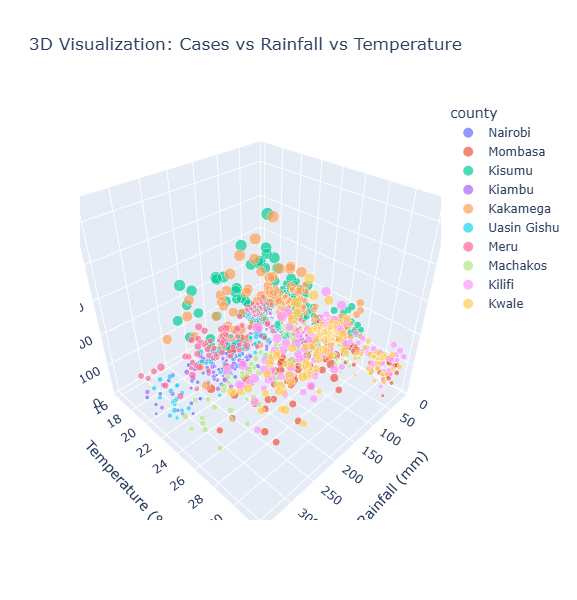

In [9]:
# 3D Scatter plot with Plotly
fig = px.scatter_3d(df, x='rainfall_mm', y='temp_mean_c', z='confirmed_cases',
                    color='county', size='confirmed_cases',
                    hover_data=['month', 'season'],
                    title='3D Visualization: Cases vs Rainfall vs Temperature',
                    labels={'rainfall_mm': 'Rainfall (mm)', 
                           'temp_mean_c': 'Temperature (°C)',
                           'confirmed_cases': 'Cases'})
fig.update_layout(height=600)
fig.show()

In [10]:
print("\n" + "="*60)
print("📊 EDA SUMMARY")
print("="*60)

print(f"\n📈 Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"📅 Date Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"📍 Counties: {df['county'].nunique()}")
print(f"🦟 Total Cases: {df['confirmed_cases'].sum():,}")
print(f"📊 Average Monthly Cases: {df['confirmed_cases'].mean():.1f}")
print(f"📈 Peak Month: {df.groupby('month')['confirmed_cases'].mean().idxmax()} (avg {df.groupby('month')['confirmed_cases'].mean().max():.1f} cases)")
print(f"📉 Lowest Month: {df.groupby('month')['confirmed_cases'].mean().idxmin()} (avg {df.groupby('month')['confirmed_cases'].mean().min():.1f} cases)")

print("\n✅✅✅ EDA COMPLETE! Ready for Feature Engineering!")


📊 EDA SUMMARY

📈 Dataset Shape: 1200 rows, 9 columns
📅 Date Range: 2015-01-01 to 2024-12-01
📍 Counties: 10
🦟 Total Cases: 158,111
📊 Average Monthly Cases: 131.8
📈 Peak Month: 3 (avg 204.7 cases)
📉 Lowest Month: 9 (avg 75.4 cases)

✅✅✅ EDA COMPLETE! Ready for Feature Engineering!


In [11]:
print("\n" + "="*60)
print("📊 EDA SUMMARY")
print("="*60)

print(f"\n📈 Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"📅 Date Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"📍 Counties: {df['county'].nunique()}")
print(f"🦟 Total Cases: {df['confirmed_cases'].sum():,}")
print(f"📊 Average Monthly Cases: {df['confirmed_cases'].mean():.1f}")
print(f"📈 Peak Month: {df.groupby('month')['confirmed_cases'].mean().idxmax()} (avg {df.groupby('month')['confirmed_cases'].mean().max():.1f} cases)")
print(f"📉 Lowest Month: {df.groupby('month')['confirmed_cases'].mean().idxmin()} (avg {df.groupby('month')['confirmed_cases'].mean().min():.1f} cases)")



📊 EDA SUMMARY

📈 Dataset Shape: 1200 rows, 9 columns
📅 Date Range: 2015-01-01 to 2024-12-01
📍 Counties: 10
🦟 Total Cases: 158,111
📊 Average Monthly Cases: 131.8
📈 Peak Month: 3 (avg 204.7 cases)
📉 Lowest Month: 9 (avg 75.4 cases)
